In [5]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np


In [10]:
X,y=make_blobs(n_samples=1000,
               centers=3,
               n_features=2,)

In [11]:
X

array([[ 7.91704091, -8.87308845],
       [ 2.33668055,  3.32675618],
       [ 2.18627116,  5.33741663],
       ...,
       [ 1.72165391,  6.1903994 ],
       [ 3.59322248,  6.84389167],
       [ 2.67628632,  3.03953407]], shape=(1000, 2))

In [12]:
y

array([1, 0, 0, 1, 0, 2, 2, 2, 1, 1, 1, 0, 2, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 2, 1, 2, 1, 2, 1, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1,
       2, 2, 0, 2, 2, 1, 1, 2, 1, 2, 2, 2, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 2, 2, 0, 0, 1, 0, 1, 0, 1, 2, 0, 1, 2, 1, 0, 0, 2,
       1, 1, 2, 0, 0, 0, 0, 1, 2, 2, 2, 0, 1, 0, 1, 2, 1, 2, 2, 1, 2, 0,
       1, 1, 2, 2, 0, 1, 1, 0, 0, 1, 2, 0, 0, 2, 2, 0, 1, 0, 0, 1, 2, 2,
       2, 0, 2, 1, 0, 1, 0, 2, 2, 1, 2, 1, 2, 1, 0, 0, 2, 1, 1, 1, 0, 0,
       1, 1, 2, 2, 2, 0, 0, 2, 1, 2, 1, 2, 1, 2, 2, 2, 0, 1, 0, 1, 2, 0,
       1, 2, 0, 1, 0, 0, 2, 2, 0, 1, 2, 2, 0, 0, 2, 2, 1, 1, 1, 2, 2, 1,
       2, 2, 2, 1, 0, 2, 2, 1, 2, 2, 1, 0, 0, 0, 2, 2, 1, 1, 0, 1, 2, 0,
       2, 1, 1, 1, 1, 0, 1, 0, 2, 2, 2, 1, 0, 1, 2, 2, 1, 0, 0, 0, 0, 1,
       1, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 1, 2, 2,
       0, 0, 2, 0, 0, 2, 0, 2, 2, 1, 1, 0, 2, 2, 2, 0, 1, 0, 2, 1, 0, 2,
       1, 2, 2, 1, 2, 0, 1, 1, 2, 0, 2, 2, 2, 2, 2,

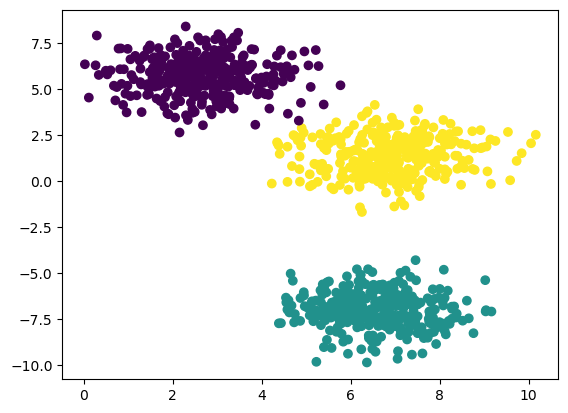

In [15]:
plt.scatter(X[:,0],X[:,1],c=y)

In [16]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [18]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [19]:
from sklearn.cluster import KMeans

In [20]:
## Elbow method to determine the number of k
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [21]:
wcss

[1599.9999999999995,
 524.5539034041974,
 200.63820910659442,
 158.68122587286672,
 126.84468173770307,
 92.39348483501384,
 79.93986917609209,
 72.0310769800742,
 68.07483630401526,
 58.210263477613836]

([<matplotlib.axis.XTick at 0x24f4dcd1810>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

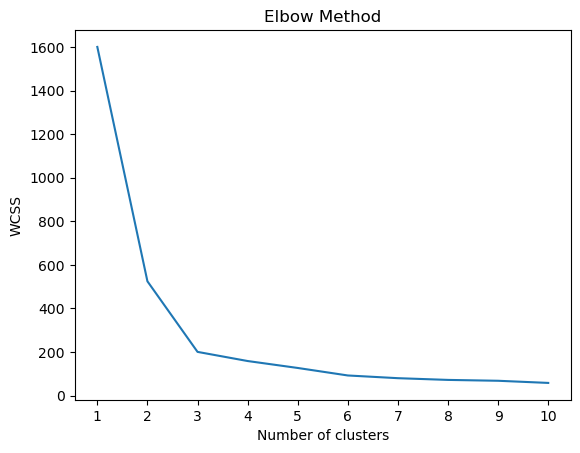

In [22]:
## plotting the elbow curve
plt.plot(range(1,11),wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.xticks(range(1,11))

In [23]:
kmeans=KMeans(n_clusters=3,random_state=42,init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([1, 1, 1, 1, 0, 2, 2, 0, 2, 2, 1, 0, 0, 2, 1, 1, 1, 2, 1, 0, 2, 1,
       0, 0, 1, 1, 2, 1, 1, 2, 2, 0, 1, 2, 1, 1, 0, 1, 0, 2, 0, 2, 2, 2,
       0, 1, 2, 0, 0, 0, 0, 0, 2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 1,
       0, 1, 1, 2, 2, 1, 1, 2, 1, 0, 2, 1, 1, 1, 0, 1, 1, 2, 1, 0, 1, 0,
       1, 1, 1, 0, 2, 1, 0, 0, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 1, 0, 2, 2,
       2, 1, 0, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 0, 2, 0, 2, 1, 0, 1,
       1, 0, 0, 1, 2, 1, 1, 0, 1, 2, 1, 1, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0,
       1, 2, 2, 0, 1, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 2, 0, 2, 1,
       2, 1, 2, 0, 1, 0, 1, 2, 2, 1, 2, 2, 1, 2, 0, 2, 1, 2, 1, 0, 1, 2,
       1, 1, 0, 2, 0, 2, 1, 1, 0, 0, 2, 0, 1, 2, 2, 1, 0, 2, 1, 2, 2, 0,
       0, 1, 1, 1, 2, 1, 2, 0, 1, 2, 2, 2, 2, 0, 2, 2, 2, 1, 0, 1, 0, 1,
       2, 2, 2, 1, 2, 0, 0, 0, 0, 2, 1, 2, 2, 1, 0, 2, 1, 1, 1, 2, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 2, 2, 1, 1, 1, 2, 2, 0,
       1, 1, 2, 2, 2, 0, 2, 0, 0, 1, 0, 1, 1, 0, 0,

In [24]:
y_pred=kmeans.predict(X_test_scaled)

In [25]:
y_pred

array([1, 2, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 2, 1, 2, 0, 0, 0, 1, 2, 2, 2,
       0, 1, 1, 2, 1, 2, 0, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 1, 2, 2, 1,
       2, 2, 2, 1, 2, 0, 1, 0, 0, 1, 2, 0, 2, 0, 0, 2, 2, 2, 1, 1, 0, 2,
       2, 1, 1, 1, 0, 1, 1, 2, 0, 0, 1, 1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 2, 0, 2, 2, 1, 0, 0, 1, 2, 1, 0, 2, 2, 0, 0, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 2, 0, 2, 2, 2, 2, 0, 1, 2, 0, 1, 1, 2, 0, 2, 2, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 2,
       2, 1, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 2, 1, 2, 2, 2, 0, 1, 0,
       1, 1], dtype=int32)

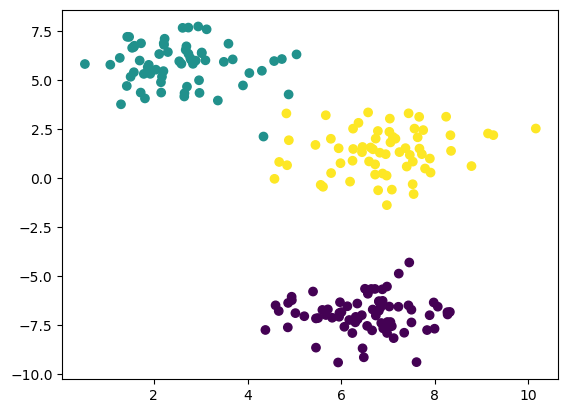

In [26]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

## For validating the k value, we will be using 2 techniques, kneelocator, Silhoutee scoring

In [28]:
#kneelocator
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [29]:
kl.elbow

np.int64(3)

In [30]:
# Silhouette Score
from sklearn.metrics import silhouette_score
silhoutte_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhoutte_coefficients.append(score)

In [31]:
silhoutte_coefficients

[0.6003904255505155,
 0.6540571927673844,
 0.5686774174837399,
 0.5059677125664882,
 0.435492749405811,
 0.4188676386484191,
 0.38814961733042497,
 0.38169538073955406,
 0.36354030902889034]

([<matplotlib.axis.XTick at 0x24f4de22fd0>,
 [Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

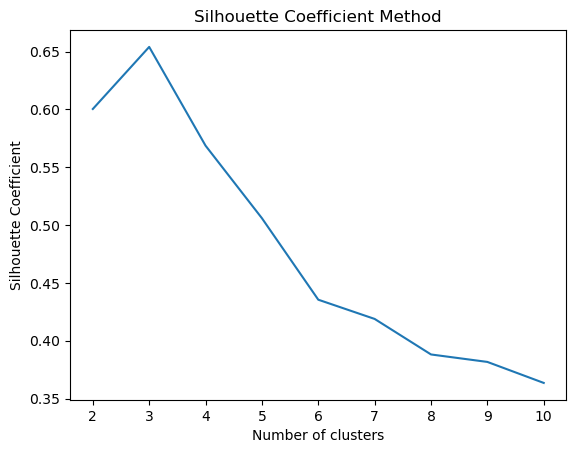

In [32]:
plt.plot(range(2,11),silhoutte_coefficients)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Coefficient Method')
plt.xticks(range(2,11))
